# Chebyshev (Tchebycheff) scalarization + SURF on a **non-convex** Pareto front

This notebook transfers the **SURF** weight-steering idea
(`2objective_SURF/surf_arxiv_knot.tex`) from *linear* scalarization (LS) to
*weighted Chebyshev* scalarization, so it applies to problems whose Pareto
front (PF) is genuinely **non-convex** (in the minimization / loss convention).

**Why replace LS?** LS solves $\min_x\, w f_1(x)+(1-w) f_2(x)$; its minimizers
lie only on the **convex hull** of the front. For a non-convex (concave) PF,
sweeping $w\in[0,1]$ recovers **only the two extreme points** — the interior is
unreachable *for any weight sampling*. SURF's weight steering cannot fix this;
it is a fundamental limitation of LS.

**Chebyshev.** $g_T(x;w)=\max\big(w(f_1-z_1^\*),\,(1-w)(f_2-z_2^\*)\big)$ with
ideal point $z^\*$. Every Pareto point (convex *or* non-convex) is a Chebyshev
minimizer for some $w$, so Chebyshev **can** traverse a non-convex front. What
remains is exactly the problem SURF solves: uniform weights give **non-uniform**
coverage. We put SURF's arc-length-CDF steering on top of Chebyshev.

**Endpoints.** At $w\in\{0,1\}$ Chebyshev ignores one objective (weakly Pareto).
We clip the sweep to $[\varepsilon,1-\varepsilon]$ with $\varepsilon=10^{-3}$;
the induced endpoints are then within $O(\varepsilon)$ of the true PF endpoints.

**Testbeds (both non-convex, no convexifying reformulation).**
- **ZDT2** — canonical non-convex benchmark, front $f_2=1-f_1^2$.
- **Circle** — concave quarter circle whose arc-length CDF $\Phi(w)$ has a
  *closed form*, so we can validate SURF's estimated $\Phi$ (paper's Rule 1 vs Rule 2).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import chebyshev_surf as cs

PyBlue, PyRed, PyGreen, PyGray = "#1f77b4", "#d62728", "#2ca02c", "#7f7f7f"
N, T, ALPHA, EPS = 15, 30, 0.3, 1e-3          # (N+1) points, T outer iters, damping, endpoint clip
np.set_printoptions(precision=4, suppress=True)

## 1. LS provably collapses on a non-convex front

We sweep $w$ uniformly over $[\varepsilon,1-\varepsilon]$ and solve the LS
subproblem exactly. On a non-convex front, only the two endpoints are ever
returned.

In [2]:
front = cs.make_front("zdt2")
w_unif = np.linspace(EPS, 1-EPS, N+1)
ls_pts = cs.sweep_points(front, w_unif, method="ls")
print("LS unique points returned:", len(np.unique(np.round(ls_pts, 4), axis=0)),
      "out of", N+1, "weights")
print(np.unique(np.round(ls_pts, 4), axis=0))

LS unique points returned: 2 out of 16 weights
[[0. 1.]
 [1. 0.]]


## 2. Chebyshev traverses the front — but uniform $w$ is non-uniform

Chebyshev reaches every part of the front, yet uniformly spaced weights bunch
up the points where the front bends.

In [3]:
ch_unif = cs.sweep_points(front, w_unif, method="cheby")
print("Chebyshev + uniform-w :", cs.all_metrics(ch_unif, front))

Chebyshev + uniform-w : {'HV': 0.11044986212919364, 'IGD': 0.025035588415950927, 'CV': 0.15234868666812212, 'GapRatio': 1.656561834033322, 'n_unique': 16}


## 3. SURF steers the weights $\Rightarrow$ uniform coverage

`cs.surf` is Algorithm 1 of the paper: at each outer iteration it (i) samples
$w_n=\Phi_t^{-1}(n/N)$, (ii) solves the Chebyshev subproblem at each $w_n$,
(iii) builds the empirical arc-length CDF from cumulative chord lengths, and
(iv) damped-updates $\Phi_{t+1}=\alpha\tilde\Phi_t+(1-\alpha)\Phi_t$.
It is scalarizer-agnostic — identical code would steer LS.

In [4]:
h = cs.surf(front, method="cheby", N=N, T=T, alpha=ALPHA, eps=EPS)
ch_surf = h["final_points"]
print("Chebyshev + SURF      :", cs.all_metrics(ch_surf, front))
print("CV by iteration:", np.array(h["cv"])[[0, 1, 2, 5, 10, 20, 30]])

Chebyshev + SURF      : {'HV': 0.11044986212919364, 'IGD': 0.0245737896232879, 'CV': 3.6092125583172457e-06, 'GapRatio': 1.0000113867433866, 'n_unique': 16}
CV by iteration: [0.1523 0.1075 0.0758 0.0264 0.0045 0.0001 0.    ]


## 4. Side-by-side: LS vs Chebyshev-uniform vs Chebyshev+SURF

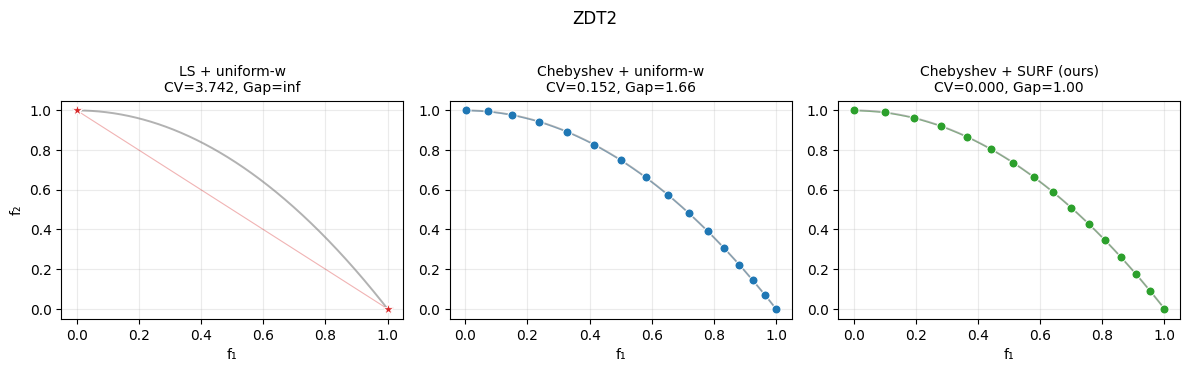

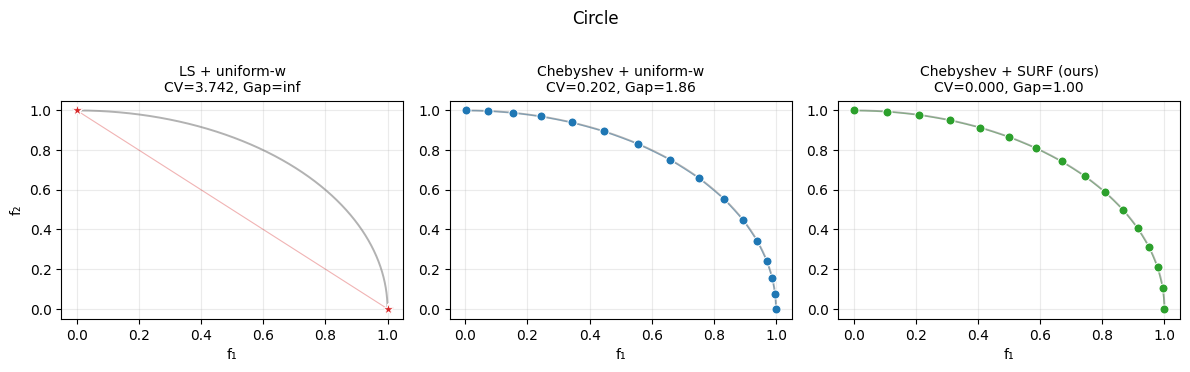

In [5]:
def show_front(name):
    fr = cs.make_front(name)
    wu = np.linspace(EPS, 1-EPS, N+1)
    data = [("LS + uniform-w", cs.sweep_points(fr, wu, method="ls"), PyRed, "*"),
            ("Chebyshev + uniform-w", cs.sweep_points(fr, wu, method="cheby"), PyBlue, "o"),
            ("Chebyshev + SURF (ours)",
             cs.surf(fr, method="cheby", N=N, T=T, alpha=ALPHA, eps=EPS)["final_points"], PyGreen, "o")]
    fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
    for a, (title, pts, col, mk) in zip(ax, data):
        a.plot(fr.pf_dense[:, 0], fr.pf_dense[:, 1], color=PyGray, lw=1.4, alpha=0.6)
        o = np.argsort(pts[:, 0])
        a.plot(pts[o, 0], pts[o, 1], color=col, lw=0.8, alpha=0.35)
        a.scatter(pts[:, 0], pts[:, 1], s=70 if mk == "*" else 42, marker=mk,
                  facecolor=col, edgecolor="white", linewidth=0.7, zorder=3)
        m = cs.all_metrics(pts, fr)
        a.set_title("%s\nCV=%.3f, Gap=%.2f" % (title, m['CV'], m['GapRatio']), fontsize=10)
        a.set_xlabel("f₁"); a.grid(alpha=0.25)
    ax[0].set_ylabel("f₂"); fig.suptitle(fr.name, y=1.02, fontsize=12)
    fig.tight_layout(); plt.show()

show_front("zdt2")
show_front("circle")

## 5. Validation on the circle: SURF's estimated $\Phi$ vs closed form

For the concave quarter circle, balancing $w\cos\theta=(1-w)\sin\theta$ gives
$\theta(w)=\arctan\!\frac{w}{1-w}$ and arc length $\propto\theta$, so the
arc-length CDF $\Phi$ is **known in closed form** (Rule 1). SURF (Rule 2)
reconstructs it from chord lengths only — and recovers the same weights.

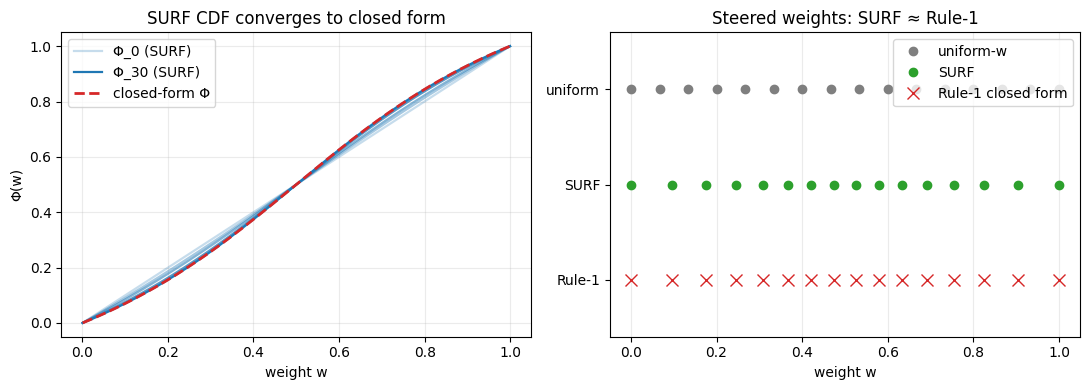

max |w_SURF - w_Rule1| = 1.0539941144305232e-06


In [6]:
fr = cs.make_front("circle")
h = cs.surf(fr, method="cheby", N=N, T=T, alpha=ALPHA, eps=EPS)
wg = h["w_grid"]
true_cdf = cs.circle_true_cdf(wg); true_cdf = (true_cdf-true_cdf[0])/(true_cdf[-1]-true_cdf[0])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for t, al in [(0, .25), (1, .4), (2, .55), (5, .75), (T, 1.)]:
    g, pv = h["phi"][t]
    ax[0].plot(g, pv, color=PyBlue, alpha=al, lw=1.6,
               label=(("Φ_%d (SURF)" % t) if t in (0, T) else None))
ax[0].plot(wg, true_cdf, "--", color=PyRed, lw=2, label="closed-form Φ")
ax[0].set_xlabel("weight w"); ax[0].set_ylabel("Φ(w)")
ax[0].set_title("SURF CDF converges to closed form"); ax[0].legend(); ax[0].grid(alpha=.25)

w_rule1 = cs.circle_rule1_weights(N, EPS)
ax[1].plot(np.linspace(EPS, 1-EPS, N+1), np.full(N+1, 2), "o", color=PyGray, label="uniform-w")
ax[1].plot(h["final_weights"], np.full(N+1, 1), "o", color=PyGreen, label="SURF")
ax[1].plot(w_rule1, np.full(N+1, 0), "x", color=PyRed, ms=8, label="Rule-1 closed form")
ax[1].set_yticks([0, 1, 2]); ax[1].set_yticklabels(["Rule-1", "SURF", "uniform"])
ax[1].set_ylim(-.6, 2.6); ax[1].set_xlabel("weight w"); ax[1].legend(); ax[1].grid(alpha=.25, axis="x")
ax[1].set_title("Steered weights: SURF ≈ Rule-1")
fig.tight_layout(); plt.show()

print("max |w_SURF - w_Rule1| =", np.abs(np.sort(w_rule1)-np.sort(h["final_weights"])).max())

## 6. Convergence of the uniformity metrics

Chord-spacing CV decays geometrically (matching the paper's
$\text{CV}=\mathcal O(N(1-c\alpha)^t)$) and the Gap Ratio $\to 1$.

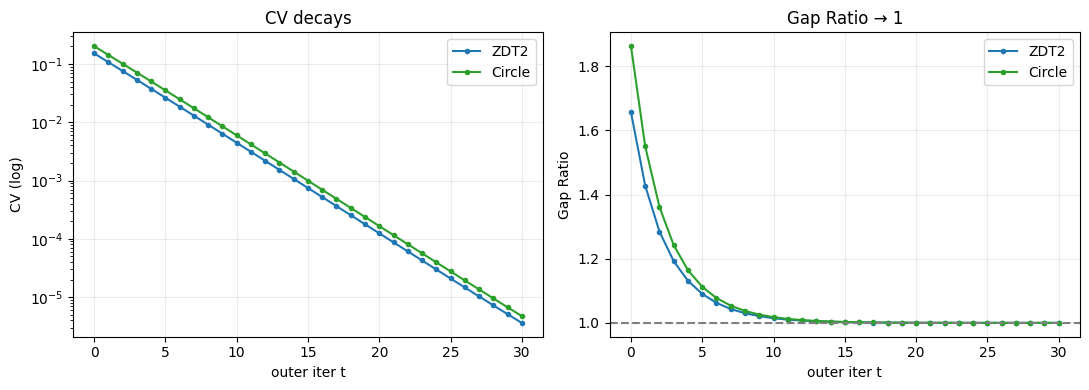

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, col in [("zdt2", PyBlue), ("circle", PyGreen)]:
    fr = cs.make_front(name)
    hh = cs.surf(fr, method="cheby", N=N, T=T, alpha=ALPHA, eps=EPS)
    it = np.arange(len(hh["cv"]))
    ax[0].semilogy(it, hh["cv"], "-o", ms=3, color=col, label=fr.name)
    ax[1].plot(it, hh["gap_ratio"], "-o", ms=3, color=col, label=fr.name)
ax[0].set_xlabel("outer iter t"); ax[0].set_ylabel("CV (log)"); ax[0].set_title("CV decays"); ax[0].grid(alpha=.25); ax[0].legend()
ax[1].axhline(1, color=PyGray, ls="--"); ax[1].set_xlabel("outer iter t"); ax[1].set_ylabel("Gap Ratio"); ax[1].set_title("Gap Ratio → 1"); ax[1].grid(alpha=.25); ax[1].legend()
fig.tight_layout(); plt.show()

## Summary

| | reaches non-convex interior? | uniform coverage? |
|---|:--:|:--:|
| **LS** (any weight sampling) | ✗ (only 2 endpoints) | — |
| **Chebyshev + uniform-$w$** | ✓ | ✗ (CV ≈ 0.15–0.20) |
| **Chebyshev + SURF** | ✓ | ✓ (CV → 0, Gap → 1) |

Chebyshev removes the convexity requirement; SURF's arc-length weight steering
then delivers uniform coverage. The $\varepsilon=10^{-3}$ endpoint clip is
enough to keep both objectives active and place the endpoints within
$O(\varepsilon)$ of the true PF corners. The circle case confirms SURF's
iterative CDF estimate matches the closed-form arc-length CDF.
